In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from numpy import random

  observation_date  TB3MS
0       01-01-1934   0.72
1       01-02-1934   0.62
2       01-03-1934   0.24
3       01-04-1934   0.15
4       01-05-1934   0.16
Maximum spot rate is = 0.163
Minimum spot rate is = 0.0001


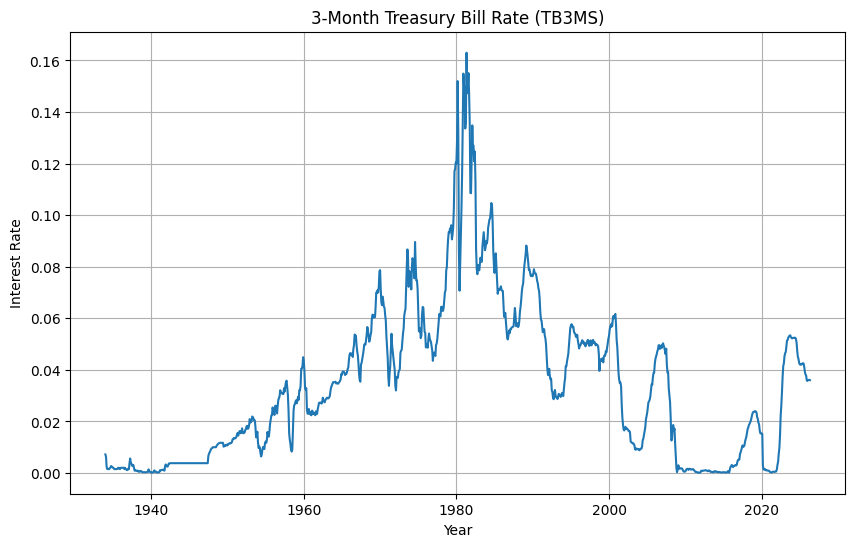

In [4]:
data = pd.read_csv("TB3MS.csv")
print(data.head())

percentage = data["TB3MS"] / 100

print("Maximum spot rate is =", percentage.max())
print("Minimum spot rate is =", percentage.min())

data["observation_date"] = pd.to_datetime(data["observation_date"],format="%d-%m-%Y")

plt.figure(figsize=(10,6))

plt.plot(data["observation_date"], percentage)

plt.title("3-Month Treasury Bill Rate (TB3MS)")
plt.xlabel("Year")
plt.ylabel("Interest Rate")
plt.grid(True)

plt.show()

# **Vasicek Model**


SDE for Vasicek model is given by,

**drₜ = Κ(μ-rₜ)dt + σdWₜ** , which can be discretised as,

r(t+Δt)-rt = ΚμΔt + (-ΚΔt)rt + σ.sqrt(Δt).ϵₜ

Δrt = ΚμΔt + (-ΚΔt)rt + σ.sqrt(Δt).ϵₜ

First step is to fit an Ordinary Least Squares (OLS) Regression line.

y = α + β.X + ϵ

Using OLS regression's slope and intercept parameters, we can estimate the parameters of Vasicek model Κ, μ and σ.

We can fit Regression on Vasicek because it is of type,

Δrt = ΚμΔt + (-ΚΔt)rt + σ.sqrt(Δt).ϵₜ where

  y = Δrt, X = rt, α = ΚμΔt, β = -ΚΔt and error term = σ.sqrt(Δt).ϵₜ



In [5]:
# Fitting the OLS regression

dt = 1/12  # dt measures the change in time, according to our data we are given spot rates for every month thus dt = 1/12

data = data.set_index("observation_date")

r = data["TB3MS"]["2000":].dropna()/100 # Using data from year 2000 only in order to reduce noise in our estimation.

X = r[:-1].values                 # X values are of type [r0,r1,r2,...,rn]
y = np.diff(r)         # y values are of type [r1-r0,r2-r1,....] which is difference of consecutive elements in array

X = sm.add_constant(X)
model_vasicek = sm.OLS(y,X)
result_1 = model_vasicek.fit()

print(result_1.summary())

intercept = result_1.params[0]
slope = result_1.params[1]

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.402
Date:                Mon, 29 Jun 2026   Prob (F-statistic):              0.122
Time:                        06:13:48   Log-Likelihood:                 1535.3
No. Observations:                 316   AIC:                            -3067.
Df Residuals:                     314   BIC:                            -3059.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000      0.726      0.4

Now using the Slope and Intercept parameters we find parameters of Vasicek model

By equating the Regression equation with Discretised Vasicek SDE and solving for κ, μ and σ we get the following values,

κ = -β / Δt

μ = α / (κ*Δt)

In the discretised SDE and OLS regression line,

Δrt = ΚμΔt + (-ΚΔt)rt + σ.sqrt(Δt).ϵₜ and y = α + β.X + e
Thus error term e = σ.sqrt(Δt).ϵₜ and ϵₜ ~ N(0,1)

std(e) = std(σ.sqrt(Δt).ϵₜ) = σ.sqrt(Δt)

Thus we get, σ = std(e) / sqrt(dt)


In [6]:
# Parameter estimate of Vasicek - kappa, mu and sigma

print("Slope =",round(slope,5),"and Intercept =",round(intercept,5))

kappa_vs = -slope / dt
mu_vs = intercept / (kappa_vs * dt)

residuals = result_1.resid

sigma_vs = np.std(residuals) / np.sqrt(dt)

r0 = r.iloc[-1]

print("kappa =",round(kappa_vs,4))
print("mu =",round(mu_vs,4))
print("volatility =",round(sigma_vs,4))
print("Initial rate 'r0' =",round(r0,3))

Slope = -0.00852 and Intercept = 0.00011
kappa = 0.1023
mu = 0.0127
volatility = 0.0065
Initial rate 'r0' = 0.036


We can simulate spot rates for next 12 months using Monte Carlo Simulation. The simulation consists of 10,000 simulations for each 12 month

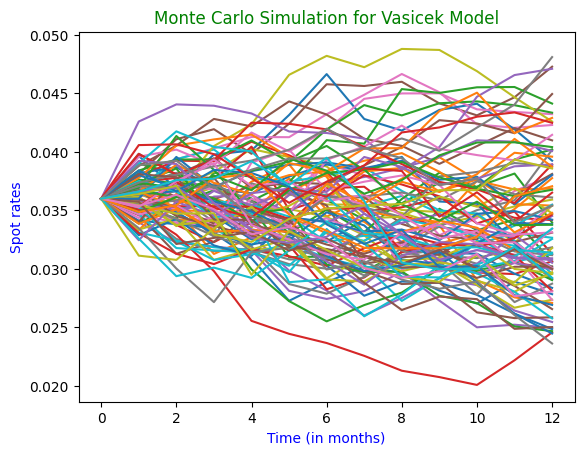

In [7]:
# Simulation of rates

total_simulations = 10000
total_months = 12

r_array_vs = np.zeros((total_simulations,total_months + 1))
r_array_vs[:,0] = r0  # Initial spot rate will be r0 = 3.6%

time_array = np.arange(total_months+1)  # Array which will be used as x-axis while plotting

for i in range(1,total_months + 1):

  # Latest value of r gets stored
  r_current = r_array_vs[:,i-1]

  # Gives Mean and Variance of the next r value
  mean = r_current + kappa_vs*(mu_vs-r_current)*dt
  var = sigma_vs**2 * dt
  sd = np.sqrt(var)

  # Samples next r value from Normal distribution
  r_next = np.random.normal(loc = mean, scale = sd)

  # Stores next r value in array
  r_array_vs[:,i] = r_next


for i in range(100):     # Plotting only 100 simulated values
  # using r_array[i,:] will only take first 100 simulations.
  plt.plot(time_array, r_array_vs[i,:])

plt.title("Monte Carlo Simulation for Vasicek Model",c = "Green")
plt.xlabel("Time (in months)",c = "Blue")
plt.ylabel("Spot rates",c = "Blue")
plt.show()

Using simulated spot rates we can price the Zero Coupon Bond at each month.

Pricing formula is P(0,t) = exp( a(0,t) - b(0,t) * rt )
where,

a(0,t) = (μ - σ^2 / (2 * κ^2) ) * ( b(0,t) - t ) - ( σ^2 * b^2(0,t) / 4κ )

b(0,t) = ( 1 / κ ) * ( 1 - exp(-κ*t ) )

In [8]:
# Zero Coupon Bond Pricing

T = 12/12 # Bond's maturity in 1 year

prices_vs = np.zeros((total_simulations,total_months+1))

for i in range(total_months+1):
  # tau gives the time to maturity
  tau = T - i/12

  if tau == 0:        # This implies if time to maturity is 0, then the bond will be worth as face value (100)
    prices_vs[:,i] = 100
  else:
    # finds value of a(0,t) and b(0,t) at different time intervals
    b = (1/kappa_vs) * (1-np.exp(-kappa_vs*tau))
    a = (mu_vs - sigma_vs**2/(2*kappa_vs**2)) * (b-tau) - (sigma_vs**2 * b**2 )/(4*kappa_vs)

    # Finds price of bond using simulated spot rates and a(0,t) and b(0,t) respective to maturities
    prices_vs[:,i] = 100 * np.exp(a - b*r_array_vs[:,i])

print(pd.DataFrame(prices_vs).head())

          0          1          2          3          4          5   \
0  96.575701  96.871068  97.215515  97.607004  97.999779  98.445979   
1  96.575701  96.940218  97.191195  97.732330  97.887147  98.047130   
2  96.575701  96.895391  97.253285  97.244072  97.560272  97.907764   
3  96.575701  96.836632  97.296871  97.661263  97.806037  98.076833   
4  96.575701  96.829561  97.072775  97.430915  97.874115  98.302368   

          6          7          8          9          10         11     12  
0  98.587188  98.764301  99.025710  99.303523  99.552362  99.759871  100.0  
1  98.386487  98.712985  98.938961  99.166484  99.519525  99.771026  100.0  
2  98.250798  98.602652  98.832759  99.077799  99.388326  99.683508  100.0  
3  98.202018  98.490277  98.865898  99.170618  99.451243  99.746588  100.0  
4  98.621420  98.933068  99.095034  99.277685  99.526429  99.780347  100.0  


Risk Metrix includes computing Duration and Convexity of Bond along with 95% and 99% Value at Risk.

Duration and Convexity has been founded using bump formula,

Duration =  - (Price_up - Price_down) / (2 * Price_base * dr)
where dr = Yield bump.

Convexity = (Price_up + Price_down - 2*Price_base ) / (Price_base * dr^2)

In [9]:
# Risk Metrix

t = 1
b_0 = (1/kappa_vs) * (1-np.exp(-kappa_vs*t))
a_0 = (mu_vs - sigma_vs**2/(2*kappa_vs**2)) * (b_0-t) - (sigma_vs**2 * b_0**2 )/(4*kappa_vs)

def price_vs(r):
  return np.exp(a_0-b_0*r)

dr = 0.0001

p_base = price_vs(r0)
p_up = price_vs(r0+dr)
p_down = price_vs(r0-dr)

Duration_vs = - (1/p_base) * (p_up - p_down)/(2*dr)
Convexity_vs = (p_down + p_up - 2*p_base)/(p_base*dr**2)
print("Bond's duration is =",round(Duration_vs,4),"years")
print("Convexity of bond is =",round(Convexity_vs,4))

VaR_95_vs = np.zeros(total_months)
VaR_99_vs = np.zeros(total_months)

for i in range(1,total_months+1):
  PnL_vs = prices_vs[:,i] - prices_vs[:,0]
  VaR_95_vs[i-1] = - np.percentile(PnL_vs,5)
  VaR_99_vs[i-1] = - np.percentile(PnL_vs,1)

VaR_vs = {
    "VaR 95%" : VaR_95_vs,
    "VaR_99%" : VaR_99_vs
}

vardf = pd.DataFrame(VaR_vs)
print(vardf)

Bond's duration is = 0.9506 years
Convexity of bond is = 0.9036
     VaR 95%   VaR_99%
0  -0.019075  0.083552
1  -0.238923 -0.104407
2  -0.499376 -0.343498
3  -0.774455 -0.619464
4  -1.068773 -0.922678
5  -1.375717 -1.232554
6  -1.692952 -1.571135
7  -2.017796 -1.917654
8  -2.357853 -2.279072
9  -2.706804 -2.646329
10 -3.062169 -3.027947
11 -3.424299 -3.424299


# **Cox-Ingersoll-Ross Model**

SDE for CIR model is given by,

drₜ = κ(μ - rₜ)dt + σ.sqrt(rₜ).dWₜ

SDE for CIR can be discretised in similar way as Vasicek model's SDE, but it's parameters cannot be estimated using OLS regression because the diffusion term σ.sqrt(rₜ) depends on rₜ meaning variance is for Δrₜ is not constant. An OLS regression assumes constant variance of residuals, just like it was for Vasicek model.

We can estimate parameters through various methods. Here I am using Method of Moments.

The long run mean for CIR is equal to μ only. Thus we can equate Sample mean with the parameter μ.

For CIR, the long run variance is equal to (σ^2.μ / 2κ). Thus we can equate Sample Variance with the long run variance (σ^2.μ / 2κ).

For a stationary process CIR, corr(rt,rt+Δt) = exp( -κ*Δt )

In [10]:
mean = np.mean(r)   # Sample mean
variance = np.var(r, ddof = 1) # Sample Variance

# We have the variable r which contains spot rates for all months from 2000 to 2026
# We need one next spot rate to find the Autocorrelation
# Also we need to use dropna() to remove last row as last row of the subsequent spot rate will give NaN, so setting it 0 creates fake observation.
# Thus we will remove whole last row.

dic = {
    "r" : r,
    "r_next" : r.shift(-1)  # Shifts rows to one next row
}

df = pd.DataFrame(dic).dropna()

print(df)

# Now I can find the Auto Correlation between r and r_next

corr = df.corr()
rho = corr.loc["r","r_next"]

mu_cir = mean

kappa_cir = - np.log(rho) / dt

sigma_cir = np.sqrt(variance*2*kappa_cir / mu_cir)

print("Kappa for CIR is =",round(kappa_cir,4))
print("Mu for CIR is =",round(mu_cir,4))
print("Volatility for CIR is =",round(sigma_cir,4))

print( "Feller's condition satisfied ?",2*kappa_cir*mu_cir > sigma_cir**2)

                       r  r_next
observation_date                
2000-01-01        0.0532  0.0555
2000-02-01        0.0555  0.0569
2000-03-01        0.0569  0.0566
2000-04-01        0.0566  0.0579
2000-05-01        0.0579  0.0569
...                  ...     ...
2025-12-01        0.0359  0.0357
2026-01-01        0.0357  0.0360
2026-02-01        0.0360  0.0361
2026-03-01        0.0361  0.0361
2026-04-01        0.0361  0.0360

[316 rows x 2 columns]
Kappa for CIR is = 0.0577
Mu for CIR is = 0.0192
Volatility for CIR is = 0.0473
Feller's condition satisfied ? False


The Feller's condition 2κμ > σ^2 is unsatisfied. This indicates the theoretical CIR process is not guranteed to remain strictly positive under the estimated parameters. However the calibrated model is retained for comparison purposes.

Again using Monte carlo simulation to simulate 10,000 spot rates under CIR model.

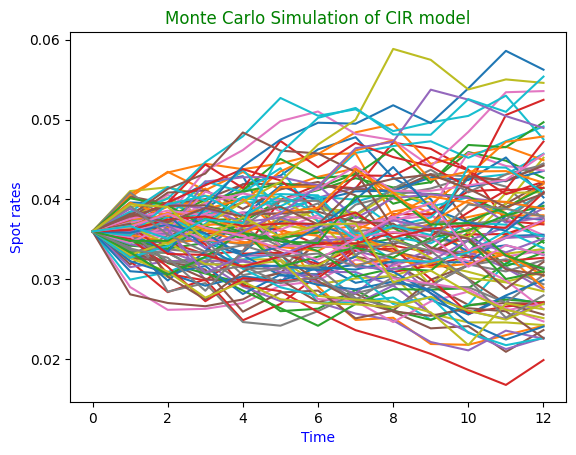

In [11]:
r_array_cir = np.zeros((total_simulations,total_months + 1))
r_array_cir[:,0] = r0

for i in range(1,total_months + 1):

  r_current_cir = r_array_cir[:,i-1]

  mean_cir = r_current_cir + kappa_cir*(mu_cir - r_current_cir)*dt

  # np.maximum(...,0) prevents sqrt of negative number
  # if rate briefly goes negative despite Feller condition check
  var_cir = sigma_cir**2 * np.maximum(r_current_cir,0) * dt
  sd_cir = np.sqrt(var_cir)

  r_next_cir = np.random.normal(loc = mean_cir, scale = sd_cir)

  r_array_cir[:,i] = r_next_cir


for i in range(100):
  plt.plot(time_array, r_array_cir[i,:])

plt.title("Monte Carlo Simulation of CIR model", c = "Green")
plt.xlabel("Time", c = "Blue")
plt.ylabel("Spot rates", c = "Blue")

plt.show()

Using simulated spot rates we can price the Zero Coupon Bond at each month.

Pricing formula is P(0,t) = exp( a(0,t) - b(0,t) * rt ) where,

a(0,t) = ( 2κμ / σ^2 ) * ln[ 2γ*exp(0.5*(γ+κ)*t / (γ+κ)*(exp(γ*t)-1)+2γ ]

b(0,t) = ( 2 * exp(γ*t -1) / (γ+κ)*(exp(γ*t)-1)+2γ )

and γ = sqrt ( κ^2 + 2σ^2 )



In [12]:
# Zero coupon bond pricing

prices_cir = np.zeros((total_simulations,total_months+1))

gamma = np.sqrt(kappa_cir**2 + 2*sigma_cir**2)

for i in range(total_months + 1):
  tau = T - i/12

  if tau == 0:
    prices_cir[:,i] = 100
  else:
    a_cir = (2*kappa_cir*mu_cir)/(sigma_cir**2) * np.log( ( 2*gamma*np.exp(0.5*(gamma+kappa_cir)*tau))/((gamma+kappa_cir)*(np.exp(gamma*tau)-1)+2*gamma))
    b_cir = (2*(np.exp(gamma*tau)-1)) / ((gamma+kappa_cir)*(np.exp(gamma*tau)-1)+2*gamma)
    prices_cir[:,i] = 100 * np.exp(a_cir - b_cir*r_array_cir[:,i])

print(pd.DataFrame(prices_cir).head())

print("Min rate across all paths/times:", r_array_cir.min())
print("Any negative rates?", (r_array_cir < 0).any())


          0          1          2          3          4          5   \
0  96.511209  96.481095  96.803518  96.936040  97.209211  98.003708   
1  96.511209  96.424983  96.489944  96.995363  97.176196  97.643759   
2  96.511209  96.900304  97.247118  97.465753  97.575620  97.714407   
3  96.511209  96.896469  97.181646  97.566390  97.808438  97.720068   
4  96.511209  96.841011  97.063425  97.799001  98.032377  98.302796   

          6          7          8          9          10         11     12  
0  98.419295  98.780814  98.993059  99.318200  99.574583  99.769060  100.0  
1  97.897844  98.199540  98.676238  99.050881  99.456874  99.704218  100.0  
2  97.977942  98.249388  98.633229  98.955844  99.239458  99.627419  100.0  
3  97.946267  98.301105  98.450383  98.852880  99.275911  99.689800  100.0  
4  98.269510  98.618492  98.930037  99.298023  99.567354  99.791401  100.0  
Min rate across all paths/times: 0.0087173168270457
Any negative rates? False


Risk Metrix - Duration, Convexity and Value at Risk at 95% and 99%

In [13]:
# Risk metrix

t = 1
a_0_cir = (2*kappa_cir*mu_cir)/(sigma_cir**2) * np.log( ( 2*gamma*np.exp(0.5*(gamma+kappa_cir)*t))/((gamma+kappa_cir)*(np.exp(gamma*t)-1)+2*gamma))
b_0_cir = (2*(np.exp(gamma*t)-1)) / ((gamma+kappa_cir)*(np.exp(gamma*t)-1)+2*gamma)

def price_cir(r):
  return np.exp(a_0_cir - b_0_cir*r)

B_base = price_cir(r0)
B_up = price_cir(r0+dr)
B_down = price_cir(r0-dr)

Duration_cir = - (1/B_base) * (B_up - B_down)/(2*dr)
Convexity_cir = (B_up + B_down - 2*B_base)/(B_base*dr**2)
print("Duration =",round(Duration_cir,4),"years")
print("Convexity =",round(Convexity_cir,4))


VaR_95_cir = np.zeros(total_months)
VaR_99_cir = np.zeros(total_months)

for i in range(1,total_months+1):
  PnL_cir = prices_cir[:,i] - prices_cir[:,0]
  VaR_95_cir[i-1] = - np.percentile(PnL_cir,5)
  VaR_99_cir[i-1] = - np.percentile(PnL_cir,1)

VaR_cir = {
    "VaR 95%" : VaR_95_cir,
    "VaR 99%" : VaR_99_cir
}

print(pd.DataFrame(VaR_cir))

Duration = 0.9714 years
Convexity = 0.9435
     VaR 95%   VaR 99%
0   0.081032  0.228250
1  -0.107026  0.106351
2  -0.332726 -0.111424
3  -0.608012 -0.348494
4  -0.906954 -0.652659
5  -1.221072 -0.985082
6  -1.569122 -1.338141
7  -1.918249 -1.722886
8  -2.289929 -2.136712
9  -2.679299 -2.567853
10 -3.076752 -3.015955
11 -3.488791 -3.488791


# **Comparison between Vasicek Model and CIR Model**

In [14]:
# Comparing parameters

para_comp = {
    "Kappa" : [kappa_vs, kappa_cir],
    "Mu" : [mu_vs, mu_cir],
    "Volatility (sigma)" : [sigma_vs, sigma_cir]
}

parameter_df = pd.DataFrame(para_comp,index = ["Vasicek","Cox-Ingersoll-Ross"])
print(parameter_df)

                       Kappa        Mu  Volatility (sigma)
Vasicek             0.102254  0.012725            0.006506
Cox-Ingersoll-Ross  0.057667  0.019166            0.047340


1. Vasicek exhibits higher mean reversion speed (κ), implying that interest rates revert to their long term mean level more quickly

2. CIR exhibits lower mean reversion speed but substantially higher volatility.

3. The estimated long term mean is higher under CIR.

4. Also CIR model violated the Feller's condition, indicating that calibrated process is not guranteed to remain positive.




In [15]:
# Comparing Duration and Convexity

risk_comp = {
    "Duration" : [Duration_vs, Duration_cir],
    "Convexity" : [Convexity_vs, Convexity_cir]
}

risk_df = pd.DataFrame(risk_comp, index = ["Vasicek", "Cox-Ingersoll-Ross"])
print(risk_df)
print("Duration is measured in 'years'")

                    Duration  Convexity
Vasicek             0.950572   0.903587
Cox-Ingersoll-Ross  0.971360   0.943541
Duration is measured in 'years'


1. Both models produce almost similar Duration estimates.

2. CIR produces higher Duration, suggesting greater sensitivity to interest rate changes.

3. CIR also produces higher convexity, indicating a marginal stronger nonlinear response to yield curve.

4. However the differences are small and unlikely to affect portfolio management decisions.

    Vasicek 95%   CIR 95%  Vasicek 99%   CIR 99%
0     -0.019075  0.081032     0.083552  0.228250
1     -0.238923 -0.107026    -0.104407  0.106351
2     -0.499376 -0.332726    -0.343498 -0.111424
3     -0.774455 -0.608012    -0.619464 -0.348494
4     -1.068773 -0.906954    -0.922678 -0.652659
5     -1.375717 -1.221072    -1.232554 -0.985082
6     -1.692952 -1.569122    -1.571135 -1.338141
7     -2.017796 -1.918249    -1.917654 -1.722886
8     -2.357853 -2.289929    -2.279072 -2.136712
9     -2.706804 -2.679299    -2.646329 -2.567853
10    -3.062169 -3.076752    -3.027947 -3.015955
11    -3.424299 -3.488791    -3.424299 -3.488791


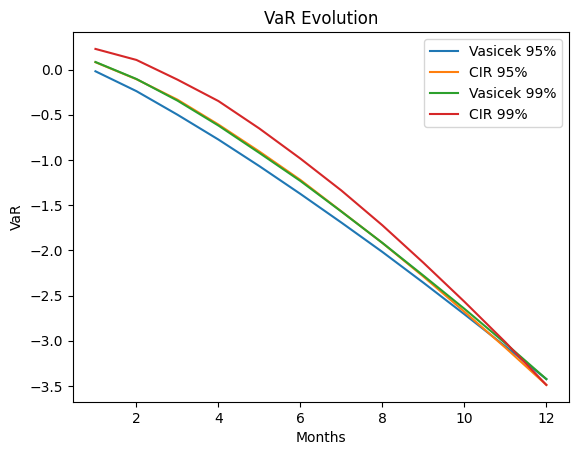

In [16]:
# Value at Risk comparison

VaR_comp = {
    "Vasicek 95%" : VaR_95_vs,
    "CIR 95%" : VaR_95_cir,
    "Vasicek 99%" : VaR_99_vs,
    "CIR 99%" : VaR_99_cir
}

VaR_df = pd.DataFrame(VaR_comp)
print(VaR_df)

plt.plot(time_array[1:], VaR_95_vs, label="Vasicek 95%")
plt.plot(time_array[1:], VaR_95_cir, label="CIR 95%")

plt.plot(time_array[1:], VaR_99_vs, label="Vasicek 99%")
plt.plot(time_array[1:], VaR_99_cir, label="CIR 99%")

plt.legend()
plt.xlabel("Months")
plt.ylabel("VaR")
plt.title("VaR Evolution")
plt.show()

1. At 1-month horizon, CIR model produces higher VaR than Vasicek model primarily due to CIR's substantially higher volatility estimate.

2. At longer horizons, 95% and 99% Value at Risk estimates produced by Vasicek and CIR models were found to be very similar.

2. Despite the different stochastic structure both models generate similar bond price distributions over the chosen simulation horizon.

3. This suggests that, for the selected calibration period and one-year horizon, the portfolio risk estimate is relatively robust to choice between Vasicek and CIR.

In [17]:
# Bond's Price comparison

price_comp = {
    "Average Price" : [np.mean(prices_vs), np.mean(prices_cir)],
    "Standard Deviation of Prices" : [np.std(prices_vs), np.std(prices_cir)]
}

price_df = pd.DataFrame(price_comp, index = ["Vasicek", "Cox-Ingersoll-Ross"])
print(price_df)

                    Average Price  Standard Deviation of Prices
Vasicek                 98.293544                      1.081256
Cox-Ingersoll-Ross      98.253828                      1.112622


In [18]:
# Simulated spot rate comparison

rate_comp = {
    "Mean rate" : [np.mean(r_array_vs), np.mean(r_array_cir)],
    "Standard deviation" : [np.std(r_array_vs), np.std(r_array_cir)],
    "Maximum rate" : [np.max(r_array_vs), np.max(r_array_cir)],
    "Minimum rate" : [np.min(r_array_vs), np.min(r_array_cir)]
}

rate_df = pd.DataFrame(rate_comp, index = ["Vasicek", "Cox-Ingersoll-Ross"])
print(rate_df)

                    Mean rate  Standard deviation  Maximum rate  Minimum rate
Vasicek              0.034898            0.004471      0.058797      0.011205
Cox-Ingersoll-Ross   0.035520            0.006244      0.078165      0.008717


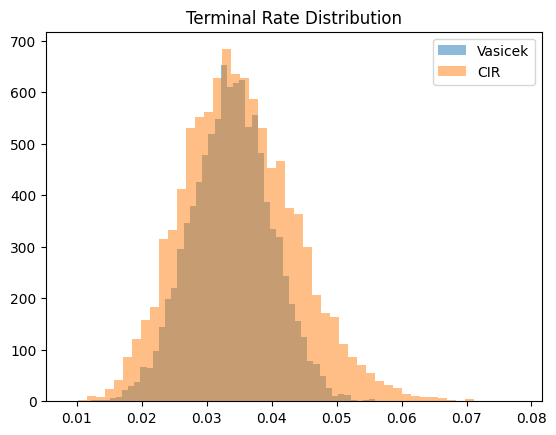

In [19]:
terminal_vs = r_array_vs[:, -1]
terminal_cir = r_array_cir[:, -1]

plt.hist(terminal_vs,
         bins=50,
         alpha=0.5,
         label="Vasicek")

plt.hist(terminal_cir,
         bins=50,
         alpha=0.5,
         label="CIR")

plt.legend()
plt.title("Terminal Rate Distribution")
plt.show()

1. This Visual demonstrates Vasicek model is approximately normal.

2. CIR is positively skewed and avoids negative rates

In [20]:
# Negative rates under both models

neg_vs = np.sum( r_array_vs < 0)
neg_cir = np.sum( r_array_cir < 0)

print("Negative rates under Vasicek =",neg_vs)
print("Negative rates under CIR =",neg_cir)

Negative rates under Vasicek = 0
Negative rates under CIR = 0


Although Vasicek model permits negative interest rates, no negative rates were observed in the simulated paths under the estimated parameters. This is because estimated volatility is 0.65% and rates are around 1.03% to 5.84%. So volatility is too small for interest rates to go negative over a 1-year horizon.